In [2]:
import numpy as np
import os
from matplotlib import pyplot as plt
from matplotlib.ticker import LogLocator, MaxNLocator, NullLocator, FixedLocator, FixedFormatter
import csv

from common import make_canvas

In [5]:
d = 4000
dstop = 800
# k = 5
# train_size = 100_000
# test_size = train_size
# train_noise = 0.2
# tol = 1e-12
# epochs = 300
# batch_size = 512

# algo_name = "Rprop"
# lr = 1e-2

plot_every = 1

filename = "icl_piecewise_losses_d8000_dstop800_lr0.0001_ep50_spe5"
with open(filename+'.csv', 'rt') as csvfile:
    data = np.genfromtxt(csvfile, delimiter=',', names=True)

epoch_range = data["epoch"].astype(np.int64)[::plot_every]
train_loss_orig = data["train_loss_orig"].astype(np.float64)[::plot_every]
test_loss_orig = data["test_loss_orig"].astype(np.float64)[::plot_every]
train_loss_cp = data["train_loss_cp"].astype(np.float64)[::plot_every]
test_loss_cp = data["test_loss_cp"].astype(np.float64)[::plot_every]
train_loss_naive = data["train_loss_naive"].astype(np.float64)[::plot_every]
test_loss_naive = data["test_loss_naive"].astype(np.float64)[::plot_every]

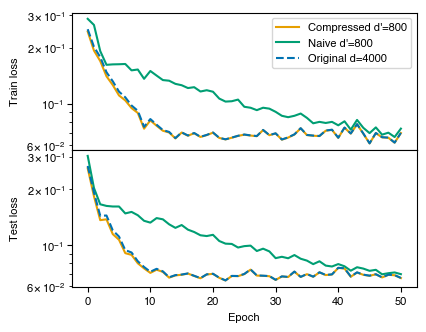

In [9]:
fig, axs = make_canvas(rows=2, cols=1, axes_width_pt=250, axes_aspect=3/4, sharex=True, gridspec_kw={'hspace': 0})

axs[0].plot(epoch_range, train_loss_cp, color="#E69F00", marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs[0].plot(epoch_range, train_loss_naive, color="#009E73", marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs[0].plot(epoch_range, train_loss_orig,  color="#0072B2", marker=None, markersize=2, ls='--', label=f'Original d={d}')
axs[0].set_yscale('log')
# axs[0].yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
# axs[0].yaxis.set_minor_locator(NullLocator()) 
axs[0].set_ylabel('Train loss')
axs[0].legend()

axs[1].plot(epoch_range, test_loss_cp, color="#E69F00", marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs[1].plot(epoch_range, test_loss_naive, color="#009E73", marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs[1].plot(epoch_range, test_loss_orig,  color="#0072B2", marker=None, markersize=2, ls='--', label=f'Original d={d}')
axs[1].set_xlabel('Epoch')
axs[1].set_yscale('log')
axs[1].set_ylabel('Test loss')

# # enforce ticks at only 0.01 and 0.02
# yticks = [0.01, 0.02]
# axs[1].yaxis.set_major_locator(FixedLocator(yticks))
# # axs[1].yaxis.set_major_formatter(FixedFormatter([f"{t:.2f}" for t in yticks]))
# axs[1].yaxis.set_minor_locator(FixedLocator([]))  # remove minor ticks

plt.tight_layout()
plt.savefig('out.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()